#### Notebook Config

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score

from pathlib import Path

In [229]:
import sys

sys.path.append(str(Path("..").resolve()))

from src.output_creator import OutputCreator
from src.graficador import Graficador

In [230]:
ROOT_DIR = Path.cwd().parent

ruta_datos = ROOT_DIR / "data" / "spotify_songs.csv"

ruta_graficos = ROOT_DIR / "outputs" / "graficos"

ruta_tablas = ROOT_DIR / "outputs" / "tablas"

df = pd.read_csv(ruta_datos)

saver = OutputCreator(ruta_tablas, ruta_graficos)
graficas = Graficador(ruta_graficos)

variables_irrelevantes = ["track_id", "track_album_id", "playlist_id", "liveness"]
df = df.drop(columns=variables_irrelevantes)

# Identificación de Factores clave en la popularidad de canciones en plataformas de streaming para la maximización de popularidad.

# 1.Comprension del Negocio

## 1.1 Problema del Negocio:

El gerente de la disquera no ha obtenido la popularidad esperada del catalogo de artistas firmados. Para ello se plantea reconocer los factores que impulsan la popularidad en plataformas digitales, y de esta manera adquirir un conocimiento acerca de las caracteristicas que hacen a una cancion popular en el mercado para tener una ventaja estategica frente a sus competidores.

---

## 1.2 Problema de Ciencia de Datos:

Bajo el contexto de realizar un modelo de clasificación se genera la variable `is_popular` en base a un threshold de la variable `track_popularity`, mas en especifico es 1 para todos aquellos datos por encima del cuartil 3, dado que el gerente necesita interpretabilidad, para seleccionar las caracteristicas que se usarán se plantea el uso de un metodo wrapper con KNN.

## 1.3 KPIs

* Incrementar el índice promedio de popularidad (0-100) de los artistas firmados
en un $30 \%$ dentro de un plazo de 8 meses.

* Identificar al menos 3 reglas de asociación que vinculen caracteristicas de las pistas de audio con la variable `is_popular`, con una caonfianza mayor al $60\%$ y lift mayor a $1.2$ en un plazo de 4 meses.

---

# 2. Consolidación del EDA.

## 2.1 Codigo extra de profundizacion de EDA1.

In [231]:
# calculo VIF variables feature

df_numerico = df.select_dtypes(include=['number'])
df_numerico = df_numerico.drop(columns=['track_popularity'])
num_features = df_numerico.columns.tolist()

In [232]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[num_features]
X_with_const = X.assign(const=1)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(len(X.columns))]

In [233]:
vif_data.sort_values(by="VIF", ascending=False)

,Variable,VIF
1,energy,2.621196
3,loudness,2.080613
6,acousticness,1.464394
0,danceability,1.295900
8,valence,1.266675
7,instrumentalness,1.131861
9,tempo,1.068227
5,speechiness,1.062603
10,duration_ms,1.051509
4,mode,1.038750


In [234]:
# Proyeccion con UMAP
import tqdm as notebook_tqdm
import umap
from sklearn.preprocessing import StandardScaler

In [235]:
X_raw = X.drop(columns=['mode']).values # eliminar variable mode 0/1 para evitar problemas con la proyeccion de UMAP
y = df['track_popularity'].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)

In [236]:
n_neighbors_vals = [5, 15, 50]
resultados_umap  = {}

print('Ejecutando UMAP con diferentes n_neighbors...')
for nn in n_neighbors_vals:
    reducer = umap.UMAP(n_components=2, n_neighbors=nn,
                        random_state=42)
    resultados_umap[nn] = reducer.fit_transform(X_sc)
    print(f'  n_neighbors={nn} ✅')

print('Listo.')

Ejecutando UMAP con diferentes n_neighbors...


d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\spectral.py:548: UserWarning:

  n_neighbors=5 ✅


d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=15 ✅


d:\Externado\tercer semestre\Data Mining\Proyecto_Data_Mining_UEC\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=50 ✅
Listo.


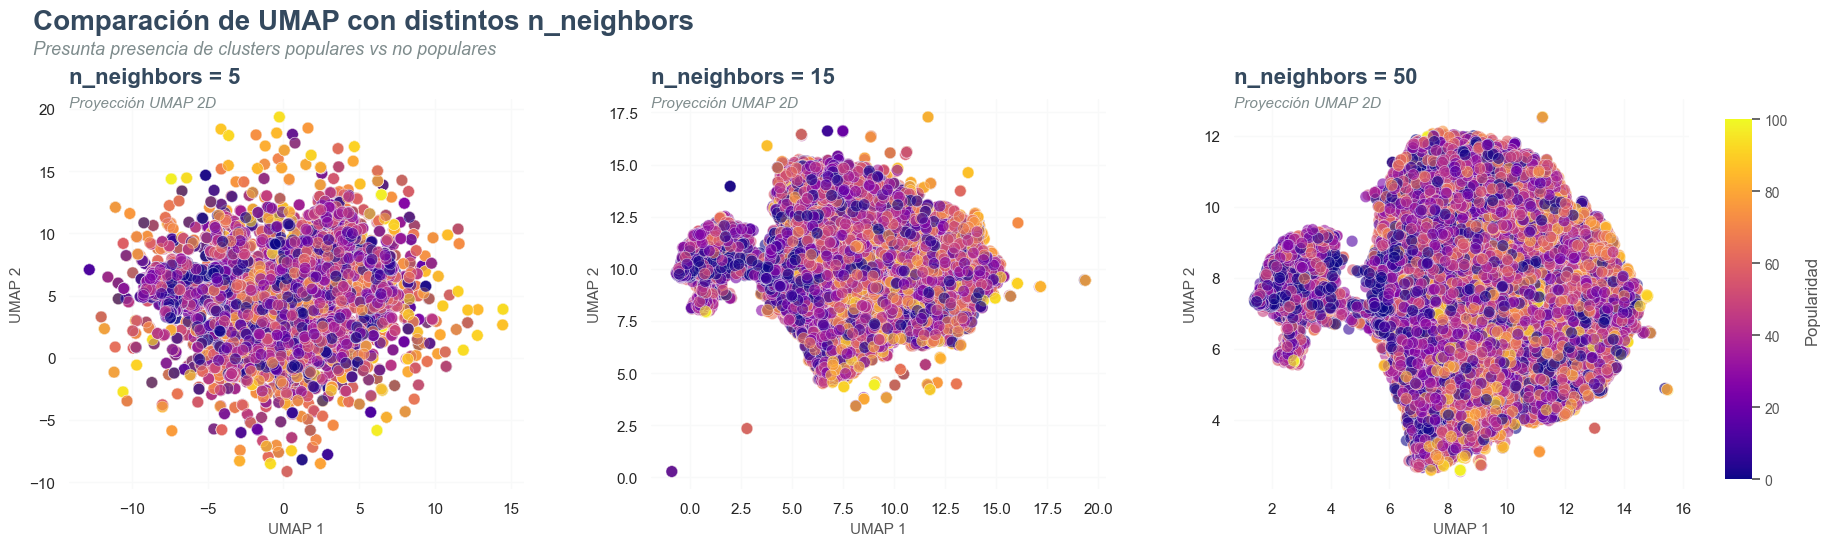

In [237]:
# --- ESTILO EDITORIAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

y = df['track_popularity'].values

# Colormap continuo: plasma va de morado oscuro → naranja → amarillo
cmap  = plt.cm.plasma
norm  = plt.Normalize(vmin=y.min(), vmax=y.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Títulos editoriales a nivel de figura
fig.text(0.04, 1.02, "Comparación de UMAP con distintos n_neighbors",
         fontsize=20, fontweight='bold', color='#34495e')
fig.text(0.04, 0.97,
         "Presunta presencia de clusters populares vs no populares",
         fontsize=13, color='#7f8c8d', style='italic')

for i, nn in enumerate(n_neighbors_vals):
    ax = axes[i]
    data_coords = resultados_umap[nn]

    ax.grid(color='#f8f9f9', linestyle='-', linewidth=1, zorder=0)

    sc = ax.scatter(
        data_coords[:, 0],
        data_coords[:, 1],
        c=y,               # variable continua como color
        cmap=cmap,
        norm=norm,
        alpha=0.6,
        s=70,
        edgecolors='white',
        linewidths=0.4,
        zorder=2
    )

    ax.set_title(f'n_neighbors = {nn}', loc='left',
                 fontweight='bold', fontsize=16, color='#34495e', pad=12)
    ax.text(0, 0.98, "Proyección UMAP 2D",
            transform=ax.transAxes, fontsize=11, color='#7f8c8d', style='italic')

    ax.set_xlabel('UMAP 1', fontsize=11, color='#555555')
    ax.set_ylabel('UMAP 2', fontsize=11, color='#555555')

    sns.despine(ax=ax, left=True, bottom=True)

# --- BARRA DE COLOR COMPARTIDA ---
# Agrega un eje estrecho a la derecha de la figura para la colorbar
cbar_ax  = fig.add_axes([0.98, 0.12, 0.015, 0.72])   # [left, bottom, width, height]
cbar     = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label('Popularidad', fontsize=12, color='#555555', labelpad=12)
cbar.ax.tick_params(labelsize=10, colors='#555555')
cbar.outline.set_visible(False)   # sin borde en la barra → limpio

plt.subplots_adjust(top=0.88, wspace=0.28, left=0.06, right=0.96, bottom=0.10)
plt.show()

## 2.2 Resultados importantes EDA1

* Univariado:
    - La popularidad es una variable dispersa, cuya probabilidad de ser un valor alto es un poco menor, ademas lo mas comun es que el indice de popularidad sea 0 (es la moda y se ve claramente el pico en el histograma), es decir es muy comun fracasar y son pocos los casos de exito

    - La industria suele utilizar canciones que duren en torno a los 3.6 minutos.

    - El valor medio de tempo es 120.88, la desviación estandar es relativamente baja respecto a la escala de la variable y el 50 % central está entre [99,96, 133,918], por lo que dicho rango indica **BPM** óptimos según la industria.

    - La industria musical, en general, parece seguir la tendencia de pistas con una energía relativamente alta.

    - El resto de variables no se pone en este documento ya que no dan información tan interpretable, sin embargo se usaran debido a su importancia para describir una pista de audio, para mas detalles sobre cada variable consulte el archivo `notebooks\EDA_&_1st_part_notebook.ipynb`. Sin embargo su uso o desuso se desidira posteriormente con tecnicas de selección de características.
* Bivariado:
    - No existe una variable que presente una relación especialmente fuerte con la popularidad.

    - Por lo general, las canciones populares (índice de popularidad > 50) suelen tener una energía ligeramente más baja que las no populares; por lo tanto, es preferible que la canción no se perciba como excesivamente ruidosa o extrema, buscando un equilibrio en la producción para llegar a un estilo ni muy lento o aburrido, pero tampoco extremadamente ruidoso.

* Multicolinealidad:
    - La variable `energy` tiene una alta correlación con `acousticness` (-0.49) y con `loudness` (0.66) lo cual podria implicar multicolinealidad, sin embargo al calcular el VIF ninguna presenta un VIF preocupante ($>5$), por lo que no es necesario considerar tratamientos de multicolinealidad.

* Outliers:
    - Se identifico que la variable cuya proporción de atipicos es mayor es `speechiness` ($9.67\%$), sin embargo, es de esperar y natural, debido a que las observaciones que posean una **speechiness** > 0,6 corresponden a contenidos hablados como pódcast, lo cual no es de interés en este caso, por lo que dichos valores tendrán que ser eliminados. Los valores por debajo de ese tope sería apropiado conservarlos, ya que probablemente correspondan a géneros altamente hablados como el rap o el hip-hop.

    - Otra variable con una cantidad considerable de atipicos es `acousticness` los outliers se pueden interpretar como la baja cantidad de canciones de las cual se tiene una alta calidad de confianza de que son acusticas (valor mayor a 0,5), lo cual indica que pistas altamente acusticas son poco comunes en la muestra.

    - LOF bajo todas las variables, solo registro **97** entradas atipicas que pueden ser eliminados o conservados, lo cual será evaluado más tarde en el proyecto.

* Exploración de  estructura:
    - Aplicando UMAP con **`n_neighbors` = 15 no se logro obtener mas de un cluster claro**, a lo mucho hay una "protuberancia" con `n_neighbors` = 15 y `n_neighbors` = 50 la cual puede difrenciarse muy poco con respecto al cluster principal y no es realmente determinante. **Es decir no hay una estructura clara separe los datos segun la popularidad (sin conocerla).**

    - Al **colorear segun la popularidad** no se observa una diferencia del color entre la masa principal y la "protuberancia". Esto se terminara de confirmar cuando se realice LDA bajo la variable que se plantea `is_popular`.

    - **Nota:** Por la naturaleza de borrador de esta proyección de UMAP aun debe tomarse por pinzas, ya que para generar dicha proyección se uso una versión escalada del dataset con StandardScaler aun ante presencia de atipicos y variables sesgadas, lo cual pudo alterar el resultado, en una fase posterior del proyecto se definira de manera mas clara que escalador usar (se podria considerar RobustScaler dado la naturaleza sesgada de algunas variables, en especial por el pico en 0 que tiene la popularidad), como tratar la asimetria antes del escalado (si se usará StandardScaler) y como tratar los atipicos (ej: eliminar los podcast).

    - **Nota2:** Se elimino la variable `mode` (naturalmente para el calculo tampoco se tomo la targuet) del calculo de la proyección para evitar una separación artificial por su naturaleza binaria.

    - Ademas tambien se usará un LDA basado en la variable binaria `is_popular` planteada, con el fin de evaluar la separación de grupos bajo ese otro metodo.


## 2.3 Posibles conclusiones

Dados los resultados obtenidos hasta el momento se puede intuir que lo mas seguro en la industria es el fracaso de una canción, sin embargo hay reglas que la industria en genral parece seguir, como lo son la duración de las canciones, el tempo, energia, etc. cuyo seguimiento puede potenciar la popularidad. Por lo cual se vuelve una opción especialmente interesante hacer uso de técnicas de mineria de patrones.

Adicionalmente, se evidencia que la popularidad no depende de una sola variable (no tiene una relacion directa con ninguna), lo cual sugiere que para poder predecir esta se tendrá que hallar alguna relación compleja en los datos que permita conocerla, no obstante, ante la dificultad de UMAP de hallar alguna estructura que separe los datos el objetivo parece complicarse, sin embargo esto podria cambiar bajo el uso de LDA que se ha planteado como hipotesis hasta el momento.

# Calidad General

## Diagnostico de datos faltantes

In [238]:
df.isnull().sum()

track_name                  5
track_artist                5
track_popularity            0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [239]:
df_nulos = df[df.isnull().any(axis=1)]
df_nulos

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms
8151,NaN,NaN,0,NaN,2012-01-05,HIP&HOP,rap,southern hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.649,95.999,282707
9282,NaN,NaN,0,NaN,2017-12-01,GANGSTA Rap,rap,gangster rap,0.678,0.659,11,-5.364,0,0.3190,0.0534,0.00000,0.191,146.153,202235
9283,NaN,NaN,0,NaN,2017-12-01,GANGSTA Rap,rap,gangster rap,0.465,0.820,10,-5.907,0,0.3070,0.0963,0.00000,0.505,86.839,206465
19568,NaN,NaN,0,NaN,2012-01-05,Reggaeton viejito🔥,latin,reggaeton,0.675,0.919,11,-6.075,0,0.0366,0.0606,0.00653,0.726,97.017,252773
19811,NaN,NaN,0,NaN,2012-01-05,latin hip hop,latin,latin hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.649,95.999,282707


Debido al bajo nivel de valores nulos se supone un mecanismo MCAR, ya que aquellos registros nulos son solo 5 y a todos ellos les hacen falta el nombre de la canción, el artista y el nombre del album, por ello se opta por su eliminación

In [240]:
df.dropna(inplace=True)

# Posicionamiento en playlists

In [241]:
df.duplicated().sum() # a primera vista no hay duplicados

np.int64(0)

In [242]:
# Definimos las columnas que mandan el criterio de duplicidad
columnas_clave = ['track_name', 'track_artist', 'track_popularity']

# Filtramos usando keep=False para ver TODAS las filas involucradas
df_revision = df[df.duplicated(subset=columnas_clave, keep="first")]

# Ordenamos para que los grupos de duplicados queden uno junto al otro
df_revision = df_revision.sort_values(by=columnas_clave)

len(df_revision), (len(df_revision)/len(df)) * 100

(4586, 13.969781893505544)

In [243]:
df['num_playlists'] = df.groupby(columnas_clave).cumcount() + 1

df = df.sort_values(by=['track_name', 'track_artist', 'track_popularity', 'num_playlists'], ascending=[True, True, True, False])

df_final = df.drop_duplicates(subset=['track_name', 'track_artist', 'track_popularity'], keep='first')

# 3. (Opcional) Reordenar el índice si lo deseas
df_final = df_final.reset_index(drop=True)

df = df_final

En realidad hay 4586 registros duplicados (sin contar la primera ocurrencia) lo cual corresponde a un 23% de la base de datos, a pesar de eso se eliminaran, no obstante ya que los registros corresponden a la misma canción pero **vienen de una playlist diferente** puede ser realmente valioso para estimar la popularidad en base a en cuantas play list aparece, por lo cual se eliminan registros duplicados (menos la primera ocurrencia) y se genera una nueva variable `num_playlists` para definir en cuentas estaba, donde 1 es un registro unico y ese numero aumentará segun la cantidad de repeticiones que tenga.

C:\Users\juanp\AppData\Local\Temp\ipykernel_14864\1667638004.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


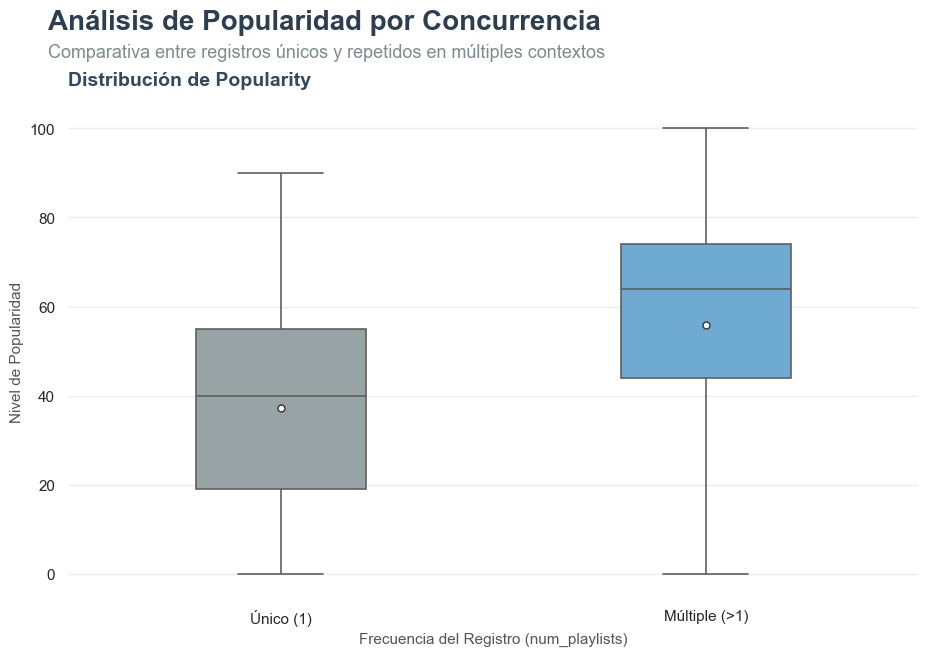

In [244]:
# @title Grafico Playlist multiple vs unica
# --- 1. PREPARACIÓN DE DATOS ---
# Creamos la columna de segmentación (si no existe)
df['grupo_playlist'] = df['num_playlists'].apply(lambda x: 'Único (1)' if x == 1 else 'Múltiple (>1)')

# --- 2. CONFIGURACIÓN GLOBAL (Look Moderno) ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#555555'

# --- 3. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(10, 7))

# TÍTULO ESTILO EDITORIAL (Alineado a la izquierda)
fig.text(0.08, 0.96, "Análisis de Popularidad por Concurrencia", fontsize=20, fontweight='bold', color='#2c3e50')
fig.text(0.08, 0.92, "Comparativa entre registros únicos y repetidos en múltiples contextos", fontsize=13, color='#7f8c8d')

# Colores suaves (Flat UI)
colores = {'Único (1)': '#95a5a6', 'Múltiple (>1)': '#5dade2'}

# --- 4. DIBUJO Y PERSONALIZACIÓN ---

# Rejilla horizontal sutil
ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

# Dibujar Boxplot
sns.boxplot(
    data=df,
    x='grupo_playlist',
    y='track_popularity',
    ax=ax,
    palette=colores,
    width=0.4,
    linewidth=1.2,
    fliersize=3,
    showmeans=True,
    meanprops={
        "marker":"o",
        "markerfacecolor":"white",
        "markeredgecolor": "#333333",
        "markersize":"5",
        "zorder": 3
    },
    zorder=2
)

# Estética del Subplot
ax.set_title("Distribución de Popularity", loc='left', fontsize=14, fontweight='bold', pad=15, color='#34495e')
ax.set_ylabel("Nivel de Popularidad", fontsize=11, fontweight='medium')
ax.set_xlabel("Frecuencia del Registro (num_playlists)", fontsize=11, fontweight='medium')

# Eliminar bordes para el look 'flat'
sns.despine(ax=ax, left=True, bottom=True)

# Ajustar espacio para que los títulos respiren
plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.15)

plt.show()

In [245]:
df.columns # Recuerde eliminar grupo_playlist

Index(['track_name', 'track_artist', 'track_popularity', 'track_album_name',
       'track_album_release_date', 'playlist_name', 'playlist_genre',
       'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence',
       'tempo', 'duration_ms', 'num_playlists', 'grupo_playlist'],
      dtype='str')

In [246]:
unico = df[df['num_playlists'] == 1]['track_popularity']
multiple = df[df['num_playlists'] > 1]['track_popularity']

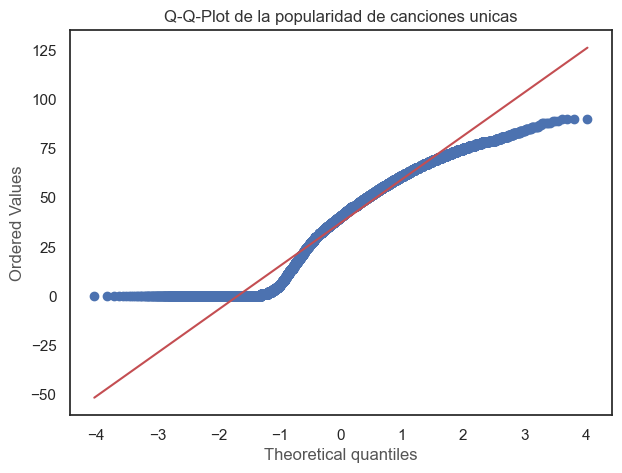

In [247]:
plt.figure(figsize=(7, 5))
stats.probplot(unico, dist="norm", plot=plt)
plt.title("Q-Q-Plot de la popularidad de canciones unicas")
plt.show()

Para verificar la diferencia visual entre los grupos y dado que no se satisface la normalidad se da paso a utilizar un prueba de hipotesis MANN-WHITNEY U dada la ausencia de normalidad.

In [248]:
u_stat, p_valor = stats.mannwhitneyu(unico, multiple)

print(f"\n--- RESULTADO MANN-WHITNEY U ---")
print(f"Estadístico U: {u_stat:.4f}")
print(f"P-valor:       {p_valor}")


--- RESULTADO MANN-WHITNEY U ---
Estadístico U: 21436679.5000
P-valor:       0.0



La prueba confirma que hay una diferencia considerable entre los grupos, por lo que un factor importante a considerar para la popularidad es considerar si sale en mas de una playlist. Por lo que un objetivo sera buscar un alto posicionamiento en playlists.

C:\Users\juanp\AppData\Local\Temp\ipykernel_14864\3734895945.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


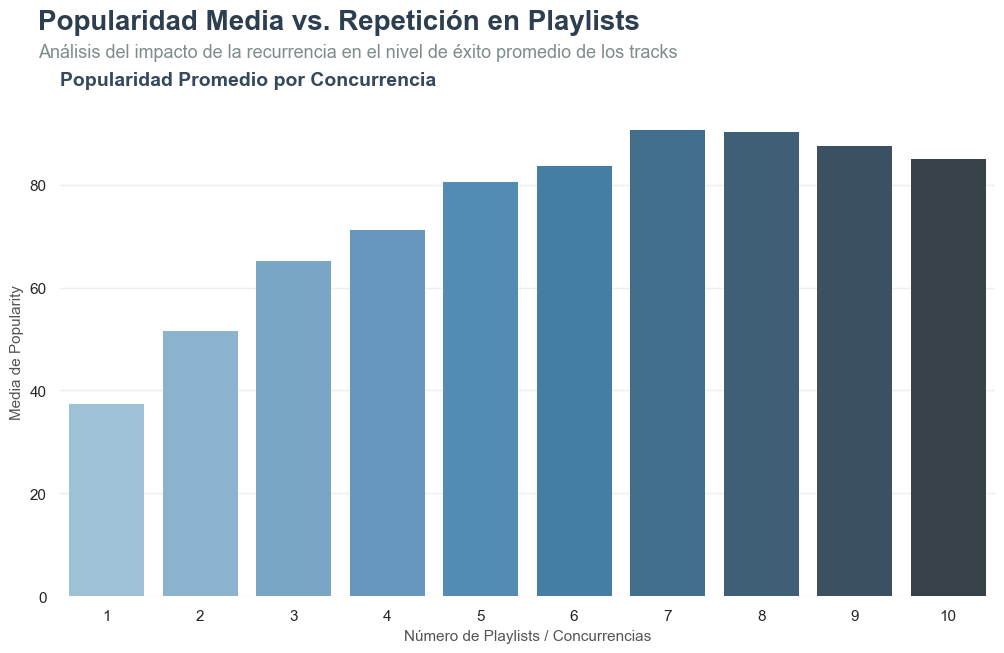

In [249]:
# 1. PREPARACIÓN DE DATOS
# Agrupamos por cantidad de playlists y calculamos la media de popularidad
df_agrupado = df.groupby('num_playlists')['track_popularity'].mean().reset_index()

# --- 2. CONFIGURACIÓN GLOBAL (Look Moderno) ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#555555'

# --- 3. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(11, 7))

# TÍTULO ESTILO EDITORIAL
fig.text(0.08, 0.96, "Popularidad Media vs. Repetición en Playlists", fontsize=20, fontweight='bold', color='#2c3e50')
fig.text(0.08, 0.92, "Análisis del impacto de la recurrencia en el nivel de éxito promedio de los tracks", fontsize=13, color='#7f8c8d')

# --- 4. DIBUJO Y PERSONALIZACIÓN ---

# Rejilla horizontal sutil
ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

# Dibujar Gráfico de Barras
# Usamos un degradado de azul para enfatizar el aumento
sns.barplot(
    data=df_agrupado,
    x='num_playlists',
    y='track_popularity',
    ax=ax,
    palette="Blues_d",  # Degradado elegante
    edgecolor='none',
    zorder=2
)

# Estética del Subplot
ax.set_title("Popularidad Promedio por Concurrencia", loc='left', fontsize=14, fontweight='bold', pad=15, color='#34495e')
ax.set_ylabel("Media de Popularity", fontsize=11, fontweight='medium')
ax.set_xlabel("Número de Playlists / Concurrencias", fontsize=11, fontweight='medium')

# Eliminar bordes para el look 'flat'
sns.despine(ax=ax, left=True, bottom=True)

# Ajustar espacio
plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.15)

plt.show()

Ademas vea como mientras las canciones estan en mas playlists tienen una popularidad media mayor. Tambien es cierto que mietras mayor es el numero de concurrencias la mmuestra es menor y por ejemplo la barra que corresponde a 9 solo representa la popularidad de una cancion.

# Preprocesamiento (selccion de escalador)

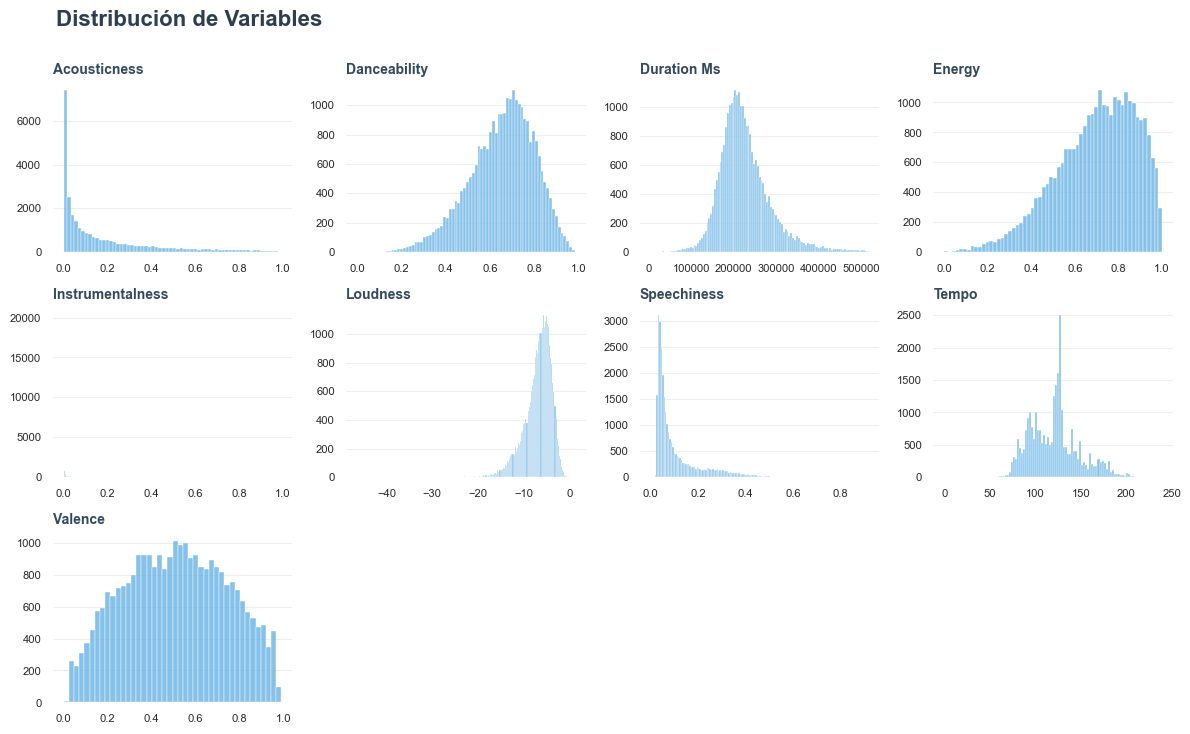

In [250]:
import math

# 1. PREPARACIÓN
df_num = df.select_dtypes(include=['number'])
columnas_numericas = df_num.columns.difference(['track_popularity', 'key', 'mode', 'num_playlists'])  # Excluir la variable objetivo
n_cols = 4  # Más columnas_numericas por fila para hacerlo más horizontal y bajo
n_rows = math.ceil(len(columnas_numericas) / n_cols)

# --- 2. CONFIGURACIÓN COMPACTA ---
sns.set_theme(style="white", context="paper") # 'paper' reduce el tamaño de fuentes automáticamente
plt.rcParams['font.family'] = 'sans-serif'

# --- 3. CREAR FIGURA PEQUEÑA ---
# Reducimos el alto (figsize) y la escala de fuente
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2.5))
axes = axes.flatten()

# TÍTULO ESTILO EDITORIAL (Más pequeño)
fig.text(0.05, 0.98, "Distribución de Variables", fontsize=16, fontweight='bold', color='#2c3e50')

# --- 4. ITERACIÓN ---
for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=0.8, zorder=0)

    sns.histplot(
        df_num[col],
        ax=ax,
        color='#5dade2',
        kde=False, # Quitamos KDE para limpiar el look en miniatura
        edgecolor='white',
        linewidth=0.3,
        zorder=2
    )

    # Títulos internos minimalistas
    ax.set_title(col.replace('_', ' ').title(), loc='left', fontsize=10, fontweight='bold', color='#34495e')
    ax.set_ylabel("") # Quitamos 'Frecuencia' para ahorrar espacio
    ax.set_xlabel("")

    sns.despine(ax=ax, left=True, bottom=True)
    ax.tick_params(axis='both', labelsize=8)

# Limpieza de vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajuste de márgenes muy ajustado
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ya que hay distribuciones que son asimetricas y que dicha asimetria/atipicos son propiedades que se desean conservar se deside usar `RobustScaler` como escalador.

In [251]:
rs = RobustScaler()

In [252]:
df_scaled = pd.DataFrame(
    rs.fit_transform(df[columnas_numericas]),
    columns=columnas_numericas,
    index=df.index
)

In [253]:
df_scaled.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,loudness,speechiness,tempo,valence
0,-0.215798,1.226131,-0.980809,-1.189394,0.268076,-0.124974,0.852174,0.529879,-1.144110
1,-0.324909,-0.773869,0.319185,-0.537879,129.845348,-1.949234,-0.359783,0.408716,-0.758904
2,-0.263844,-0.592965,0.970283,0.443182,0.608985,0.354394,2.406522,-0.967571,0.156164
3,-0.253257,-0.592965,0.970283,0.454545,0.492318,0.360774,2.417391,-0.969129,0.134247
4,1.242671,0.638191,-0.367645,0.939394,0.020652,0.848186,-0.088043,-0.410068,0.153425


# Preprocesamiento (Generar Variable targuet `is_popular`)

Se generara una variable booleana `is_popular` cuyo valor es true si la popularidad esta sobre el cuartil 3

In [254]:
q3_popularity = df['track_popularity'].quantile(0.75)

# 2. Creamos la variable booleana
# Será True si la popularidad es estrictamente mayor al Q3
df['is_popular'] = df['track_popularity'] > q3_popularity

# Verificamos cuántos registros califican como "populares"
print(f"Umbral de popularidad (Q3): {q3_popularity}")
print(df['is_popular'].value_counts())
df['is_popular'] = df['is_popular'].astype(bool)

Umbral de popularidad (Q3): 58.0
is_popular
False    21420
True      6822
Name: count, dtype: int64


C:\Users\juanp\AppData\Local\Temp\ipykernel_14864\3337931774.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\juanp\AppData\Local\Temp\ipykernel_14864\3337931774.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Populares (75%)', 'Populares (Top 25%)'])


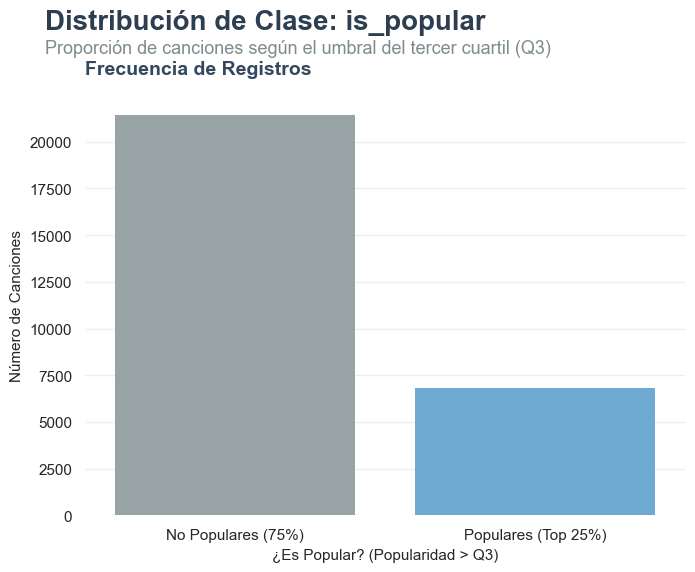

In [255]:
# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'

# --- 2. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(8, 6))

# TÍTULO ESTILO EDITORIAL
fig.text(0.1, 0.96, "Distribución de Clase: is_popular", fontsize=20, fontweight='bold', color='#2c3e50')
fig.text(0.1, 0.92, "Proporción de canciones según el umbral del tercer cuartil (Q3)", fontsize=13, color='#7f8c8d')

# --- 3. DIBUJO Y PERSONALIZACIÓN ---

# Colores: Gris para la mayoría, Azul para tu objetivo (éxitos)
paleta_binaria = {'False': '#95a5a6', 'True': '#5dade2'}

# Rejilla horizontal sutil
ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

# Dibujar Barplot (usando countplot para que cuente automáticamente los True/False)
sns.countplot(
    data=df,
    x='is_popular',
    ax=ax,
    palette=paleta_binaria,
    edgecolor='none',
    zorder=2
)

# Estética del Subplot
ax.set_title("Frecuencia de Registros", loc='left', fontsize=14, fontweight='bold', pad=15, color='#34495e')
ax.set_ylabel("Número de Canciones", fontsize=11, fontweight='medium')
ax.set_xlabel("¿Es Popular? (Popularidad > Q3)", fontsize=11, fontweight='medium')

# Etiquetas del eje X más descriptivas
ax.set_xticklabels(['No Populares (75%)', 'Populares (Top 25%)'])

# Eliminar bordes para el look 'flat'
sns.despine(ax=ax, left=True, bottom=True)

# Ajustar espacio
plt.subplots_adjust(top=0.85, left=0.15, right=0.9, bottom=0.15)

plt.show()

In [256]:
df.drop(columns=['grupo_playlist', 'track_name', 'track_artist'], inplace=True)

In [257]:
df.drop(columns=['track_album_name', ], inplace=True)

In [258]:
df.drop(columns=['playlist_name', ], inplace=True)

In [259]:
df.drop(columns=['track_album_release_date', ], inplace=True)

In [260]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_popularity   28242 non-null  int64  
 1   playlist_genre     28242 non-null  str    
 2   playlist_subgenre  28242 non-null  str    
 3   danceability       28242 non-null  float64
 4   energy             28242 non-null  float64
 5   key                28242 non-null  int64  
 6   loudness           28242 non-null  float64
 7   mode               28242 non-null  int64  
 8   speechiness        28242 non-null  float64
 9   acousticness       28242 non-null  float64
 10  instrumentalness   28242 non-null  float64
 11  valence            28242 non-null  float64
 12  tempo              28242 non-null  float64
 13  duration_ms        28242 non-null  int64  
 14  num_playlists      28242 non-null  int64  
 15  is_popular         28242 non-null  bool   
dtypes: bool(1), float64(8), int64(5),

In [261]:
df['grupo_playlist'] = df['num_playlists'].apply(lambda x: 0 if x == 1 else 1) # 1 para múltiples, 0 para únicos

# Codificación de variables categóricas

In [262]:
df_cat = df.select_dtypes(include=['str'])

In [263]:
df_cat.head()

,playlist_genre,playlist_subgenre
0,rap,gangster rap
1,pop,electropop
2,rap,southern hip hop
3,rap,hip hop
4,r&b,hip pop


In [264]:
valores_unicos = df_cat.nunique().sort_values(ascending=False)
df_resumen_cat = valores_unicos.to_frame(name='Valores Únicos')

print("Resumen de diversidad en variables categóricas:")
df_resumen_cat

Resumen de diversidad en variables categóricas:


,Valores Únicos
playlist_subgenre,24
playlist_genre,6


Hay 2 variables categoricas, `playlist_subgenre` y `playlist_genre`, a la primera se le aplicara un encoding utilizando un Target Encoding (con especial precaucion de sufrir una fuga de datos) para utilizar la informacion de popularidad por genero, y a la segunda un One-hot encoding para evitar el peligro de darle un orden artificial a los datos.

<small><b>Nota:</b> Se eliminan variables como el nombre de la cancion o el artista por su naturaleza de identificar canciones, en especial se elimina el artista para evitar que el modelo adquiera sesgo hacia artistas de base populares como Lady Gaga o Justin Bieber, de tal modo que solo se base en la musica y no en nombres populares (ademas tienen una cardinalidad alitisma).</small>

In [265]:
df_main_genre = pd.get_dummies(df, columns=['playlist_genre'], drop_first=True, dtype=int)
df_main_genre.head()

,track_popularity,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,tempo,duration_ms,num_playlists,is_popular,grupo_playlist,playlist_genre_latin,playlist_genre_pop,playlist_genre_r&b,playlist_genre_rap,playlist_genre_rock
0,18,gangster rap,0.914,0.408,10,-6.712,0,0.1410,0.026800,0.001790,...,140.026,150909,1,False,0,0,0,0,1,0
1,34,electropop,0.516,0.580,9,-13.288,0,0.0295,0.000002,0.857000,...,135.903,238227,1,False,0,0,1,0,0,0
2,0,southern hip hop,0.552,0.839,2,-4.984,1,0.2840,0.015000,0.004040,...,89.070,281960,1,False,0,0,0,0,1,0
3,48,hip hop,0.552,0.842,8,-4.961,1,0.2850,0.017600,0.003270,...,89.017,281960,1,False,0,0,0,0,1,0
4,26,hip pop,0.797,0.970,3,-3.204,1,0.0545,0.385000,0.000157,...,108.041,192094,1,False,0,0,0,1,0,0


In [266]:
# dividir en train y test, evitar data leakage
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [267]:
media_subgenre_train = train.groupby('playlist_subgenre', observed=False)['track_popularity'].mean()
print(f'\nMedia de popularidad por subgénero (calculada SOLO sobre train):')
print(media_subgenre_train.round(4))


Media de popularidad por subgénero (calculada SOLO sobre train):
playlist_subgenre
album rock                   33.8169
big room                     29.8714
classic rock                 39.6985
dance pop                    44.1060
electro house                35.1096
electropop                   37.4703
gangster rap                 33.2590
hard rock                    36.7364
hip hop                      51.2610
hip pop                      51.8676
indie poptimism              39.7500
latin hip hop                39.0017
latin pop                    44.0443
neo soul                     32.3886
new jack swing               28.3928
permanent wave               53.7885
pop edm                      45.3942
post-teen pop                48.7798
progressive electro house    27.0595
reggaeton                    49.0132
southern hip hop             34.0138
trap                         46.9406
tropical                     41.7282
urban contemporary           46.4379
Name: track_popularity, dtyp

In [268]:
train = train.copy()
test  = test.copy()
train['subgenre_target_enc'] = train['playlist_subgenre'].map(media_subgenre_train)
test['subgenre_target_enc']  = test['playlist_subgenre'].map(media_subgenre_train)

In [269]:
train

,track_popularity,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms,num_playlists,is_popular,grupo_playlist,subgenre_target_enc
5493,65,latin,latin pop,0.607,0.737,1,-5.362,1,0.0618,0.1210,0.000000,0.319,140.016,216919,1,True,0,44.044260
10969,56,r&b,neo soul,0.563,0.751,6,-4.325,1,0.3170,0.0141,0.000000,0.487,85.789,324307,1,False,0,32.388633
2001,54,rap,southern hip hop,0.585,0.697,1,-6.126,0,0.3570,0.0339,0.000000,0.402,133.177,225187,1,False,0,34.013817
22157,54,rap,gangster rap,0.790,0.394,0,-9.938,0,0.0671,0.0626,0.000522,0.104,134.148,115075,1,False,0,33.258986
311,45,edm,progressive electro house,0.763,0.727,3,-10.549,0,0.1300,0.0433,0.000256,0.531,115.020,284308,1,False,0,27.059492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,51,latin,tropical,0.607,0.535,4,-11.633,1,0.0441,0.6380,0.000958,0.562,82.057,236362,1,False,0,41.728227
5390,51,edm,electro house,0.859,0.748,0,-7.756,1,0.1400,0.2070,0.004530,0.524,122.990,197226,1,False,0,35.109589
860,0,edm,progressive electro house,0.525,0.853,4,-5.258,1,0.0843,0.0106,0.000207,0.456,154.940,228867,1,False,0,27.059492
15795,40,latin,tropical,0.558,0.258,7,-13.022,0,0.0554,0.8550,0.000004,0.256,125.942,212284,1,False,0,41.728227


# Consolidar df final con variables numéricas escaladas, target encoding y dummies

In [270]:
df_completo = pd.concat([train, test]).sort_index()
df_final = df_scaled.combine_first(df_completo)
cols_adicionales = df_completo.columns.difference(df_scaled.columns)

# Creamos el DF definitivo juntando las adicionales con las escaladas
df_final = pd.concat([df_scaled, df_completo[cols_adicionales]], axis=1)

In [271]:
df_final.drop(columns=['track_popularity', 'playlist_subgenre'], inplace=True)

In [272]:
df_final.drop(columns=['num_playlists'], inplace=True)

In [274]:
df_final = pd.get_dummies(df_final, columns=['playlist_genre'], drop_first=True, dtype=int)
df_final.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,loudness,speechiness,tempo,valence,grupo_playlist,is_popular,key,mode,subgenre_target_enc,playlist_genre_latin,playlist_genre_pop,playlist_genre_r&b,playlist_genre_rap,playlist_genre_rock
0,-0.215798,1.226131,-0.980809,-1.189394,0.268076,-0.124974,0.852174,0.529879,-1.144110,0,False,10,0,33.258986,0,0,0,1,0
1,-0.324909,-0.773869,0.319185,-0.537879,129.845348,-1.949234,-0.359783,0.408716,-0.758904,0,False,9,0,37.470309,0,1,0,0,0
2,-0.263844,-0.592965,0.970283,0.443182,0.608985,0.354394,2.406522,-0.967571,0.156164,0,False,2,1,34.013817,0,0,0,1,0
3,-0.253257,-0.592965,0.970283,0.454545,0.492318,0.360774,2.417391,-0.969129,0.134247,0,False,8,1,51.261013,0,0,0,1,0
4,1.242671,0.638191,-0.367645,0.939394,0.020652,0.848186,-0.088043,-0.410068,0.153425,0,False,3,1,51.867596,0,0,1,0,0


In [276]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   acousticness          28242 non-null  float64
 1   danceability          28242 non-null  float64
 2   duration_ms           28242 non-null  float64
 3   energy                28242 non-null  float64
 4   instrumentalness      28242 non-null  float64
 5   loudness              28242 non-null  float64
 6   speechiness           28242 non-null  float64
 7   tempo                 28242 non-null  float64
 8   valence               28242 non-null  float64
 9   grupo_playlist        28242 non-null  int64  
 10  is_popular            28242 non-null  bool   
 11  key                   28242 non-null  int64  
 12  mode                  28242 non-null  int64  
 13  subgenre_target_enc   28242 non-null  float64
 14  playlist_genre_latin  28242 non-null  int64  
 15  playlist_genre_pop    28242 no

# Evaluación de Correlaciones y distribuciones en el dataset tratado

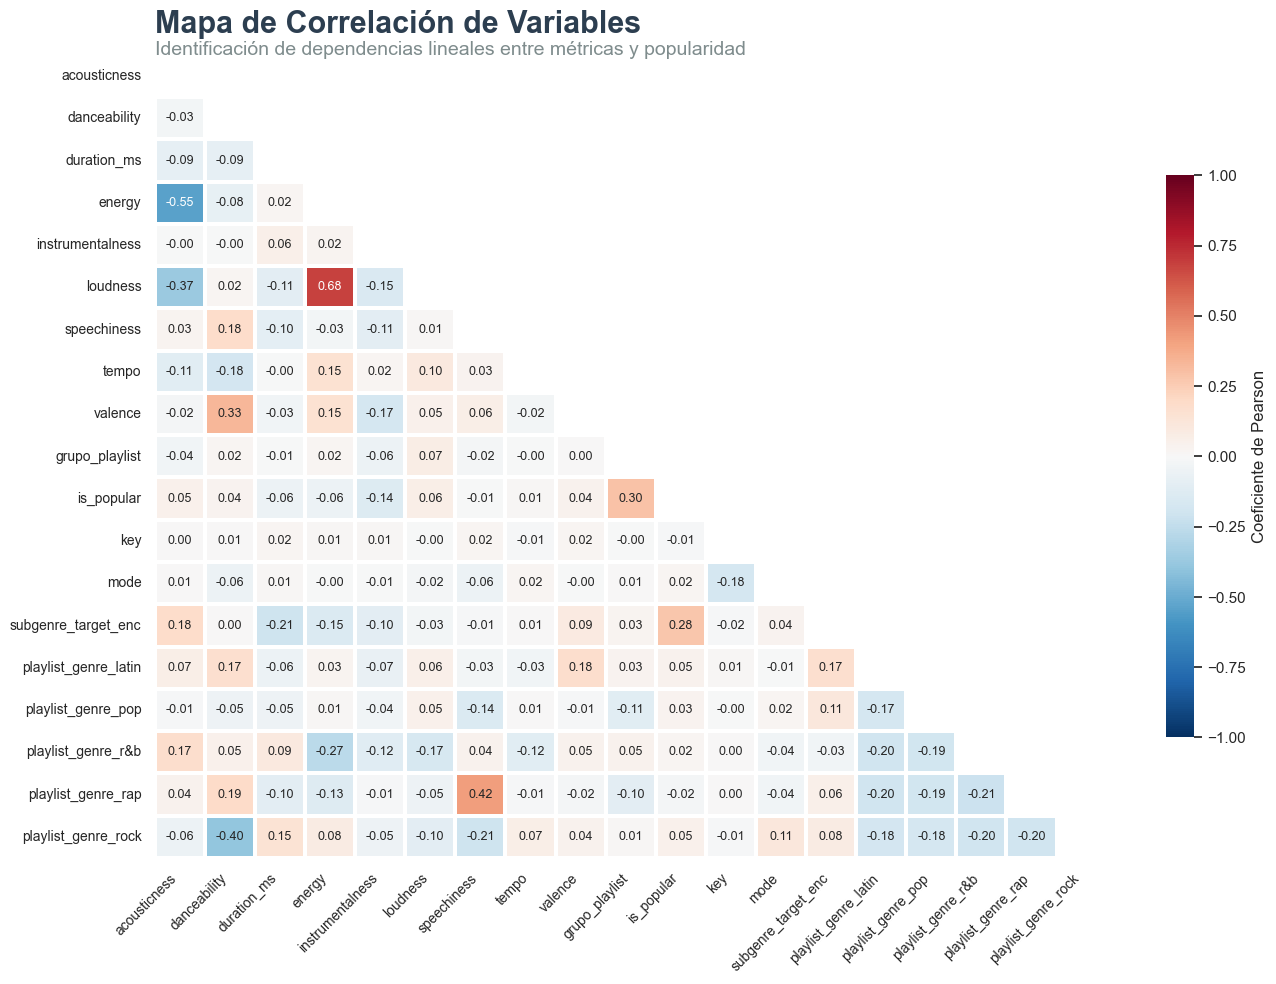

In [290]:
# --- 1. CONFIGURACIÓN GLOBAL ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'

# --- 2. CÁLCULO DE CORRELACIÓN ---
# Calculamos la matriz de Pearson
corr = df_final.corr()

# Generamos una máscara para el triángulo superior (para evitar redundancia visual)
mask = np.triu(np.ones_like(corr, dtype=bool))

# --- 3. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(14, 11))

# TÍTULO ESTILO EDITORIAL
fig.text(0.1, 0.90, "Mapa de Correlación de Variables", fontsize=22, fontweight='bold', color='#2c3e50')
fig.text(0.1, 0.88, "Identificación de dependencias lineales entre métricas y popularidad", fontsize=14, color='#7f8c8d')

# --- 4. DIBUJO DEL HEATMAP ---
# Usamos una paleta divergente (RdBu_r) para ver claro lo positivo y negativo
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    vmax=1, vmin=-1, center=0,
    annot=True,          # Añade los valores numéricos
    fmt=".2f",           # Dos decimales
    linewidths=1.5,      # Espacio blanco entre celdas (estilo flat)
    cbar_kws={"shrink": .7, "label": "Coeficiente de Pearson"},
    ax=ax,
    annot_kws={"size": 9}
)

# Estética de los ejes
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Ajuste de márgenes
plt.subplots_adjust(top=0.88, left=0.1, right=0.95, bottom=0.15)

plt.show()

Es importante resaltar que la variable que mas influye en la popularidad es el grupo playlist (unica o multiple), probablemente en un proceso de seleccion de caracteristicas esta sea la variable mas potente a la hora de predecir `is_popular`.

# Evaluacion con LDA.

Antes de aplicar LDA es fundamental mencionar que no se cumple ni el supuesto de normalidad ni el de homocedasticidad, sin embargo se evaluara de manera empirica su rendimiento para separar los grupos.

In [303]:
caracteristicas = list(df_final.columns)
caracteristicas.remove('is_popular')

In [305]:
X_raw = df_final[caracteristicas].values
y = df_final['is_popular'].values
clases = np.unique(y)

In [308]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X_raw, y)

# Convertimos a DataFrame para visualizarlo con tu estilo
df_lda = pd.DataFrame(X_lda, columns=['LD1'])
df_lda['is_popular'] = y

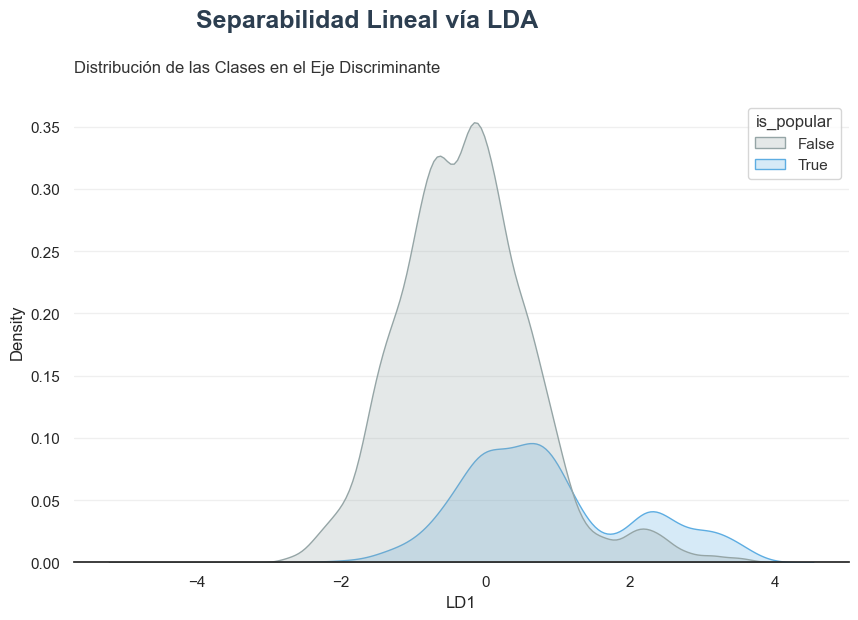

In [315]:
plt.figure(figsize=(10, 6))

# Título estilo editorial
plt.text(-4, 0.43, "Separabilidad Lineal vía LDA", fontsize=18, fontweight='bold', color='#2c3e50')

sns.kdeplot(data=df_lda, x='LD1', hue='is_popular', fill=True, palette={True: '#5dade2', False: '#95a5a6'})

plt.title("Distribución de las Clases en el Eje Discriminante", loc='left', pad=20)
sns.despine(left=True)
plt.grid(axis='y', alpha=0.3)
plt.show()

Como era de esperar por la falta tan drastica de supuestos LDA no funciono de una buena forma.

# Evaluacion con metodo wrapper

In [318]:
knn_t = KNeighborsClassifier(n_neighbors=5)

# 1. Definir X e y claramente
X = df_final.drop(columns=['is_popular'])
y = df_final['is_popular']
X_raw = X.values # Convertir a numpy para el selector

resultados_musica = {'forward': [], 'backward': []}

for direction in ['forward', 'backward']:
    for n_feat in range(1, X.shape[1]):
        sfs = SequentialFeatureSelector(knn_t, n_features_to_select=n_feat,
                                        direction=direction, cv=5, scoring='accuracy')
        sfs.fit(X_raw, y)
        vars_sel = list(X.columns[sfs.get_support()])
        score = cross_val_score(knn_t, X_raw[:, sfs.get_support()],
                                y, cv=5, scoring='accuracy').mean()
        resultados_musica[direction].append({
            'n_vars': n_feat, 'variables': vars_sel, 'accuracy': score
        })

df_fwd = pd.DataFrame(resultados_musica['forward'])
df_bwd = pd.DataFrame(resultados_musica['backward'])

print("SFS Forward — Music:")
for _, r in df_fwd.iterrows():
    print(f"  {r['n_vars']} var(s): {r['variables']}  →  acc={r['accuracy']:.4f}")

print("\nSFS Backward — Music:")
for _, r in df_bwd.iterrows():
    print(f"  {r['n_vars']} var(s): {r['variables']}  →  acc={r['accuracy']:.4f}")

KeyboardInterrupt: 